In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
def running_avg(x, n_windows):
    '''Computes a running average over x'''
    ws = int(len(x)/n_windows)  # size of each window
    return [np.sum(x[i*ws:i*ws+ws])/ws for i in range(int(len(x)/ws))]

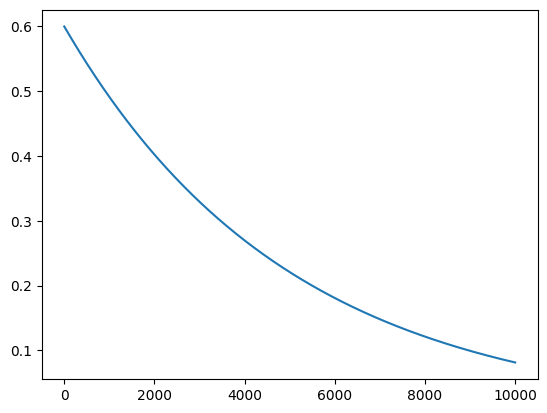

In [30]:
decay = 0.6 * (0.9998 ** np.arange(10_000))
plt.plot(decay)

# Error plot

In [38]:
list_dir = [
    '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_0',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_2',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_3',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_4',
]

In [39]:
num_episodes = 10_000
n_windows = 500

aggr_rew = np.zeros((len(list_dir), num_episodes))

for i, out_dir in enumerate(list_dir):
    cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
    aggr_rew[i, :] = cum_reward["x"][:num_episodes]

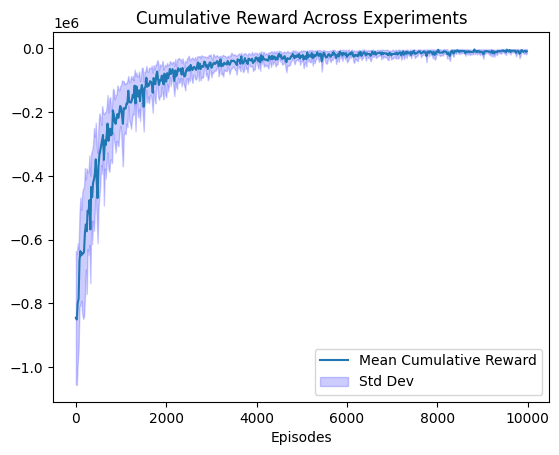

In [40]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_rew, axis=0), n_windows), label='Mean Cumulative Reward')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_rew, axis=0) - np.std(aggr_rew, axis=0), n_windows),
                running_avg(np.mean(aggr_rew, axis=0) + np.std(aggr_rew, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Cumulative Reward Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()

In [41]:
aggr_trains = np.zeros((len(list_dir), num_episodes))
for i, out_dir in enumerate(list_dir):
    arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))
    aggr_trains[i, :] = arrived_trains["x"][:num_episodes]

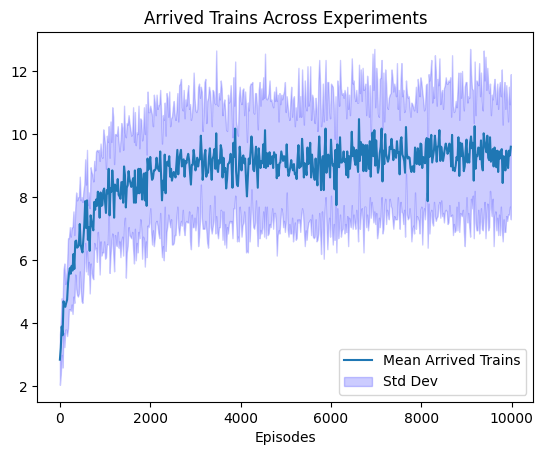

In [42]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_trains, axis=0), n_windows), label='Mean Arrived Trains')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_trains, axis=0) - np.std(aggr_trains, axis=0), n_windows),
                running_avg(np.mean(aggr_trains, axis=0) + np.std(aggr_trains, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Arrived Trains Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()


# Eval

In [43]:
def barplot(list_dir, num_evals, num_agents):
    hist_data = np.zeros((len(list_dir*num_evals), 3))

    for idx, exp_dir in enumerate(list_dir):
        
        data = np.zeros((num_evals, 3))
        for i in range(num_evals):

            delays = np.load(os.path.join(exp_dir, f"eval_{i}", "delays.npz"))
            delays = delays["x"]

            trains_at_dest = np.load(os.path.join(exp_dir, f"eval_{i}", "trains_at_dest.npz"))
            trains_at_dest = trains_at_dest["x"]

            mask = np.zeros(num_agents).astype(bool)
            mask[trains_at_dest] = True
            arrived_negatives = np.sum(mask & (delays <= 0))
            arrived_positives = np.sum(mask & (delays > 0))
            not_arrived = np.sum(~mask)

            data[i, :] = [arrived_negatives, arrived_positives, not_arrived]

        hist_data[idx*num_evals:idx*num_evals+num_evals] = data
        
    labels = ['Arrived Early', 'Arrived Late', 'Not Arrived']

    fig, ax = plt.subplots()
    ax.bar(labels, np.mean(hist_data, axis=0), yerr=np.std(hist_data, axis=0))
    ax.hlines(num_agents, xmin=-0.5, xmax=2.5, color='r', linestyle='--', label='Total # of Trains')
    ax.set_title('Train Arrival Status')
    ax.set_ylabel('Number of Trains')
    plt.show()

    return hist_data

In [44]:
list_dir = [
    '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_0',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/15_agents_malf_hard_BIS/exp_0/seed_2',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_3',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_4',
]

num_agents = 15
num_evals = 10


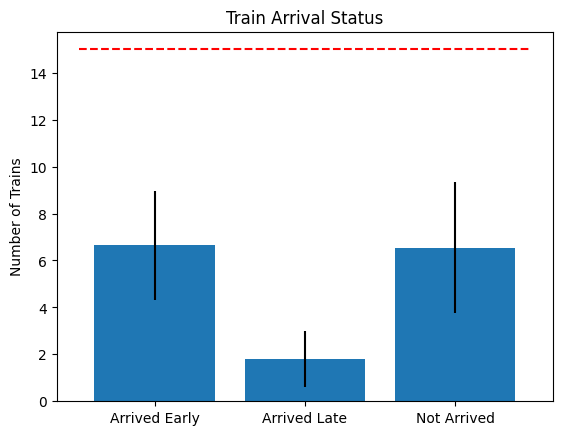

In [45]:
hist_data = barplot(list_dir, num_evals, num_agents)

In [32]:
list_dir = [
    '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_0',
    '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_2',
    '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_3',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init_TRIS/exp_0/seed_4',
]

num_agents = 15
num_evals = 10

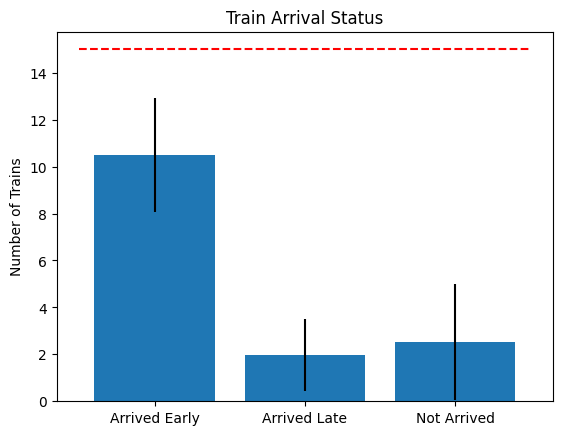

In [33]:
hist_data_2 = barplot(list_dir, num_evals, num_agents)

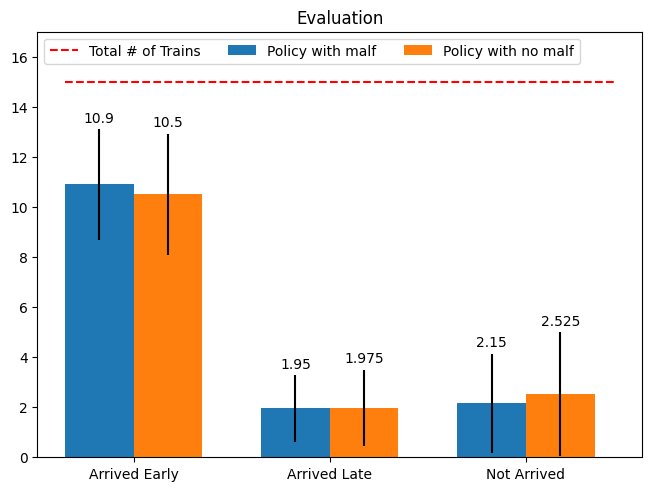

In [35]:
means = {
    'Policy with malf': [np.mean(hist_data, axis=0), np.std(hist_data, axis=0)],
    'Policy with no malf': [np.mean(hist_data_2, axis=0), np.std(hist_data_2, axis=0)]
}

labels = ['Arrived Early', 'Arrived Late', 'Not Arrived']
x = np.arange(3)  # the label locations
width = 0.35  # the width of the bars
multiplier = 0.5

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement[0], width, yerr=measurement[1], label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title('Evaluation')
ax.set_xticks(x + width, labels)
ax.hlines(num_agents, xmin=0, xmax=2.8, color='r', linestyle='--', label='Total # of Trains')
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0,num_agents+2)

plt.show()

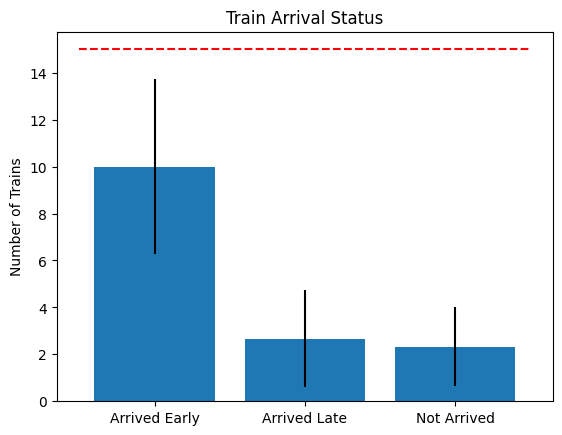

In [ ]:
hist_data = np.zeros((len(list_dir), 3))
for idx, exp_dir in enumerate(list_dir):
    delays = np.load(os.path.join(exp_dir, "eval", "delays.npz"))
    delays = delays["x"]

    trains_at_dest = np.load(os.path.join(exp_dir, "eval", "trains_at_dest.npz"))
    trains_at_dest = trains_at_dest["x"]

    mask = np.zeros(num_agents).astype(bool)
    mask[trains_at_dest] = True
    arrived_negatives = np.sum(mask & (delays <= 0))
    arrived_positives = np.sum(mask & (delays > 0))
    not_arrived = np.sum(~mask)

    hist_data[idx, :] = [arrived_negatives, arrived_positives, not_arrived]

labels = ['Arrived Early', 'Arrived Late', 'Not Arrived']

fig, ax = plt.subplots()
ax.bar(labels, np.mean(hist_data, axis=0), yerr=np.std(hist_data, axis=0))
ax.hlines(num_agents, xmin=-0.5, xmax=2.5, color='r', linestyle='--', label='Total # of Trains')
ax.set_title('Train Arrival Status')
ax.set_ylabel('Number of Trains')
plt.show()

In [ ]:
list_dir = [
    "/home/gianvito/Documents/flatland-baselines/40_agents_hp/seed_0/",
    "/home/gianvito/Documents/flatland-baselines/40_agents_hp/seed_1/",
    "/home/gianvito/Documents/flatland-baselines/40_agents_hp/seed_2/",
    "/home/gianvito/Documents/flatland-baselines/40_agents_hp/seed_3/",
    "/home/gianvito/Documents/flatland-baselines/40_agents_hp/seed_4/"
]

num_agents = 40